In [3]:
import os

data_dir = "data"

class_counts = {}
for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

print("Jumlah data per kelas:")
for k, v in class_counts.items():
    print(f"{k}: {v}")

Jumlah data per kelas:
Cherry brown_spot: 614
Cherry Leaf Scorch: 1101
Cherry Normal leaf: 500
Cherry purple leaf spot: 987
Cherry_shot hole disease: 440


Dataset tidak seimbang (imbalanced)
- Kelas terbesar: Cherry Leaf Scorch (1101)
- Kelas terkecil: Cherry_shot hole disease (440)

Karena Model berpotensi bias ke kelas mayoritas, akan ditangani dengan class_weight

In [4]:
from PIL import Image
import numpy as np


#cek ukuran gambar dan rationya
sizes = []

for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    
    for img_name in os.listdir(class_path)[:50]:  # sample saja biar cepat
        img_path = os.path.join(class_path, img_name)
        try:
            img = Image.open(img_path)
            sizes.append(img.size)  # (width, height)
        except:
            continue

# Analisis ukuran
widths = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

print("Rata-rata width:", np.mean(widths))
print("Rata-rata height:", np.mean(heights))
print("Min size:", min(sizes))
print("Max size:", max(sizes))

Rata-rata width: 800.0
Rata-rata height: 1000.0
Min size: (800, 1000)
Max size: (800, 1000)


Semua gambar memiliki resolusi yang seragam, tidak ada variasi ukuran

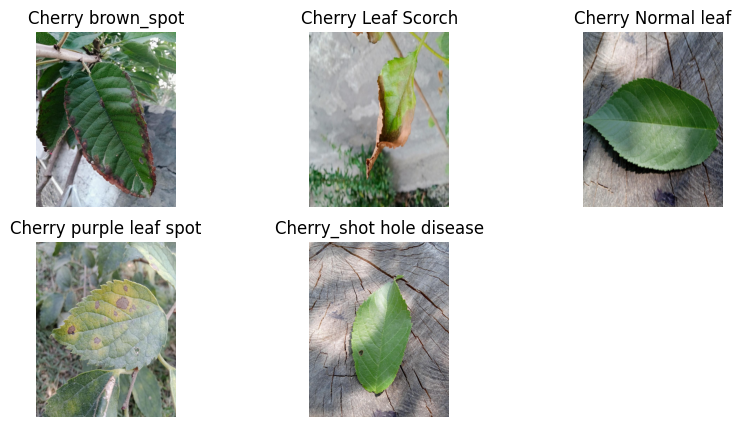

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

i = 1
for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    img_name = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    plt.subplot(2,3,i)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')
    
    i += 1

plt.show()

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import splitfolders

# Ukuran input sesuai AlexNet
img_size = (224, 224)
batch_size = 32

# Generator awal
datagen = ImageDataGenerator(
    rescale=1./255  # normalisasi pixel 0-255 → 0-1
)

# Split dataset menjadi train/val/test (70:15:15)
input_folder = "data"
output_folder = "dataset_split"

splitfolders.ratio(
    input_folder,
    output=output_folder,
    seed=42,  # agar reproducible
    ratio=(0.7, 0.15, 0.15)
)

# TRAIN GENERATOR
train_gen = ImageDataGenerator(
    rescale=1./255,                 # normalisasi
    
    rotation_range=10,              # rotasi gambar
    width_shift_range=0.05,          # geser horizontal
    height_shift_range=0.05,         # geser vertical
    
    zoom_range=0.1,                 # zoom lebih besar
    
    horizontal_flip=True,           # flip horizontal
    
    brightness_range=[0.9, 1.1],    # variasi cahaya (penting untuk daun)
    
    fill_mode='nearest'             # isi pixel kosong setelah transformasi
)

# VALIDATION GENERATOR
val_gen = ImageDataGenerator(
    rescale=1./255  # hanya normalisasi agar evaluasi fair
)

# TEST GENERATOR
test_gen = ImageDataGenerator(
    rescale=1./255  # hanya normalisasi
)

# LOAD DATA TRAIN
train_data = train_gen.flow_from_directory(
    "dataset_split/train",
    target_size=img_size,           # konsisten pakai variabel
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True                   # biar training tidak bias urutan
)

# LOAD DATA VALIDATION
val_data = val_gen.flow_from_directory(
    "dataset_split/val",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False                  # tidak perlu shuffle
)

# LOAD DATA TEST
test_data = test_gen.flow_from_directory(
    "dataset_split/test",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False                  # untuk evaluasi & confusion matrix
)

Copying files: 3642 files [00:05, 621.68 files/s]

Found 2547 images belonging to 5 classes.


Found 546 images belonging to 5 classes.
Found 549 images belonging to 5 classes.


Seluruh gambar diubah ukurannya menjadi 224x224 piksel agar sesuai dengan arsitektur AlexNet, serta dilakukan normalisasi pixel dengan skala 0 hingga 1. Selanjutnya, dataset dibagi menjadi tiga bagian yaitu data training (70%), validation (15%), dan testing (15%) menggunakan metode stratified split untuk menjaga proporsi kelas tetap seimbang

In [7]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = train_data.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(classes),
    y=classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: 0.6615584415584416, 1: 1.4554285714285715, 2: 1.1874125874125874, 3: 0.7382608695652174, 4: 1.653896103896104}


### 2b.

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# AlexNet Baseline Model 
model = Sequential()

# LAYER 1: CONV + POOL
# Convolution 11x11, stride 4 → output: 54x54x96
model.add(Conv2D(96, (11,11), strides=4, activation='relu', input_shape=(224,224,3)))

# MaxPool 3x3, stride 2 → output: 26x26x96
model.add(MaxPooling2D(pool_size=(3,3), strides=2))


# LAYER 2: CONV + POOL
# Convolution 5x5, padding=2 → output: 26x26x256
# (padding='same' ≈ pad=2)
model.add(Conv2D(256, (5,5), padding='same', activation='relu'))

# MaxPool 3x3, stride 2 → output: 12x12x256
model.add(MaxPooling2D(pool_size=(3,3), strides=2))



# LAYER 3: CONV
# Convolution 3x3, padding=1 → output: 12x12x384
model.add(Conv2D(384, (3,3), padding='same', activation='relu'))


# LAYER 4: CONV
# Convolution 3x3, padding=1 → output: 12x12x384
model.add(Conv2D(384, (3,3), padding='same', activation='relu'))


# LAYER 5: CONV
# Convolution 3x3, padding=1 → output: 12x12x256
model.add(Conv2D(256, (3,3), padding='same', activation='relu'))

# MaxPool 3x3, stride 2 → output: 5x5x256
model.add(MaxPooling2D(pool_size=(3,3), strides=2))

# Flatten → 5x5x256 = 6400 neuron
model.add(Flatten())

# Dense 4096 neuron + ReLU
model.add(Dense(4096, activation='relu'))

# Dropout 0.5
model.add(Dropout(0.5))

# Dense 4096 neuron + ReLU
model.add(Dense(4096, activation='relu'))

# Dropout 0.5
model.add(Dropout(0.5))



# OUTPUT LAYER
# Dense 1000 → DIUBAH jadi 5 (karena dataset 5 kelas)
model.add(Dense(5, activation='softmax'))

model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 54, 54, 96)        34944     
                                                                 
 max_pooling2d (MaxPooling2  (None, 26, 26, 96)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 26, 26, 256)       614656    
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 12, 12, 256)       0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 12, 12, 384)       885120    
                                                                 
 conv2d_3 (Conv2D)           (None, 12, 12, 384)      

In [9]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    class_weight=class_weights
)


Epoch 1/15


80/80 [==============================] - 70s 851ms/step - loss: 1.7288 - accuracy: 0.1747 - val_loss: 1.6054 - val_accuracy: 0.2711
Epoch 2/15
80/80 [==============================] - 50s 629ms/step - loss: 1.6106 - accuracy: 0.2018 - val_loss: 1.6118 - val_accuracy: 0.1209
Epoch 3/15
80/80 [==============================] - 50s 627ms/step - loss: 1.6107 - accuracy: 0.1712 - val_loss: 1.6065 - val_accuracy: 0.3022
Epoch 4/15
80/80 [==============================] - 51s 633ms/step - loss: 1.6108 - accuracy: 0.1516 - val_loss: 1.6113 - val_accuracy: 0.2711
Epoch 5/15
80/80 [==============================] - 54s 668ms/step - loss: 1.6104 - accuracy: 0.2501 - val_loss: 1.6102 - val_accuracy: 0.1374
Epoch 6/15
80/80 [==============================] - 51s 632ms/step - loss: 1.6105 - accuracy: 0.1531 - val_loss: 1.6097 - val_accuracy: 0.1374
Epoch 7/15
80/80 [==============================] - 53s 660ms/step - loss: 1.6106 - accuracy: 0.2073 - val_loss: 1.6067 - val_accuracy: 0.3

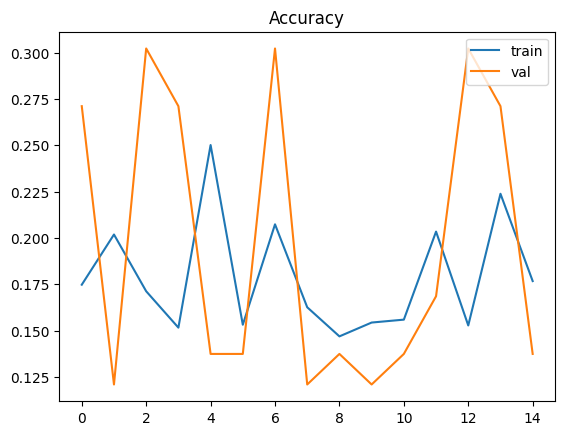

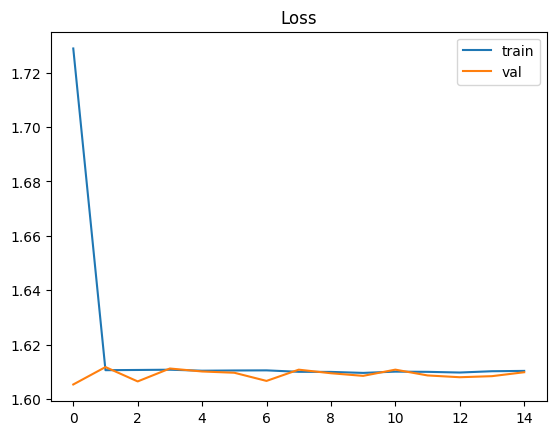

In [10]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.legend()
plt.show()

# Loss
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.legend()
plt.show()

In [11]:
model_2b = model

Model baseline AlexNet tidak mampu mempelajari pola dataset dengan baik, ditunjukkan oleh akurasi yang rendah dan loss yang stagnan. Hal ini menunjukkan terjadinya underfitting, kemungkinan karena arsitektur terlalu kompleks dan tidak stabil untuk dataset yang digunakan.

### 1c.

* Menambahkan **Batch Normalization** setelah Conv layer untuk menstabilkan distribusi data dan mempercepat konvergensi sehingga model dapat belajar lebih efektif (mengatasi underfitting)

* Mengganti **Flatten → GlobalAveragePooling2D** agar representasi fitur lebih ringkas dan membantu model fokus pada fitur penting sehingga pembelajaran menjadi lebih optimal

* Mengurangi ukuran **Fully Connected layer (4096 → 256 & 128)** karena dataset tidak begitu besar, sehingga model lebih mudah dilatih dan tidak kesulitan dalam menangkap pola data (mengurangi underfitting akibat kompleksitas berlebih)

* Menambahkan **Dropout (0.5 & 0.4)** untuk menjaga keseimbangan pembelajaran agar model tidak terlalu bergantung pada neuron tertentu dan tetap mampu generalisasi dengan baik

* Mengubah **learning rate (Adam 0.001 → 0.0003)** membuat training lebih stabil sehingga model dapat belajar pola data secara bertahap dan tidak gagal konvergen seperti pada 2b

* Menambahkan **EarlyStopping** untuk menghentikan training saat model sudah mencapai performa optimal sehingga menghindari proses training yang tidak efektif

* Menambahkan **ReduceLROnPlateau** untuk menurunkan learning rate saat model stagnan sehingga membantu model keluar dari kondisi tidak belajar

* Menyesuaikan **data augmentation (rotation, zoom, brightness, shift)** agar data menjadi lebih beragam sehingga model mendapatkan variasi yang cukup untuk belajar pola dengan lebih baik



Secara keseluruhan, saya menyesuaikan kompleksitas model agar lebih sesuai dengan dataset sehingga model dapat belajar dengan optimal dan mengatasi permasalahan underfitting yang terjadi pada baseline model.


In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(
    rescale=1./255,
    
    rotation_range=15,        # lebih stabil
    zoom_range=0.15,
    
    width_shift_range=0.05,
    height_shift_range=0.05,
    
    horizontal_flip=True,
    
    brightness_range=[0.9,1.1],  # jangan terlalu ekstrem
    
    fill_mode='nearest'
)

val_gen = ImageDataGenerator(rescale=1./255)

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D

model = Sequential()

# Block 1
model.add(Conv2D(96, (11,11), strides=4, activation='relu', input_shape=(224,224,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(3,3), strides=2))

# Block 2
model.add(Conv2D(256, (5,5), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(3,3), strides=2))

# Block 3
model.add(Conv2D(384, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())

model.add(Conv2D(384, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())

model.add(Conv2D(256, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(3,3), strides=2))

# GANTI FLATTEN → GAP 
model.add(GlobalAveragePooling2D())

# Dense lebih kecil (hindari overfit)
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.4))

# Output
model.add(Dense(5, activation='softmax'))

In [14]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model.compile(
    optimizer=Adam(learning_rate=0.0003), 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
80/80 [==============================] - 49s 591ms/step - loss: 1.3794 - accuracy: 0.5340 - val_loss: 2.3158 - val_accuracy: 0.2711 - lr: 3.0000e-04
Epoch 2/20
80/80 [==============================] - 48s 595ms/step - loss: 0.9082 - accuracy: 0.6985 - val_loss: 1.2374 - val_accuracy: 0.5311 - lr: 3.0000e-04
Epoch 3/20
80/80 [==============================] - 47s 586ms/step - loss: 0.7753 - accuracy: 0.7534 - val_loss: 1.5028 - val_accuracy: 0.4048 - lr: 3.0000e-04
Epoch 4/20
80/80 [==============================] - 48s 595ms/step - loss: 0.6173 - accuracy: 0.8005 - val_loss: 1.9624 - val_accuracy: 0.4469 - lr: 3.0000e-04
Epoch 5/20
80/80 [==============================] - 48s 597ms/step - loss: 0.5341 - accuracy: 0.8280 - val_loss: 1.1361 - val_accuracy: 0.5220 - lr: 3.0000e-04
Epoch 6/20
80/80 [==============================] - 48s 596ms/step - loss: 0.4872 - accuracy: 0.8406 - val_loss: 2.4660 - val_accuracy: 0.4945 - lr: 3.0000e-04
Epoch 7/20
80/80 [======================

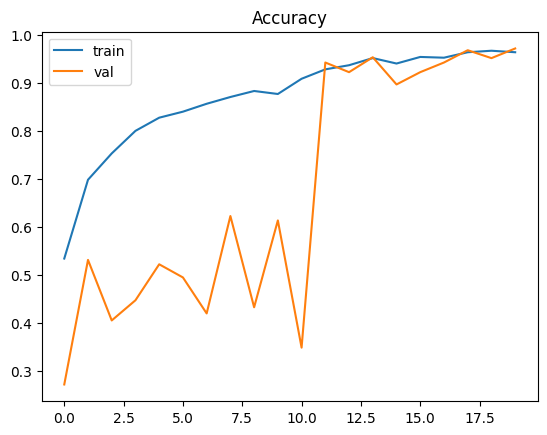

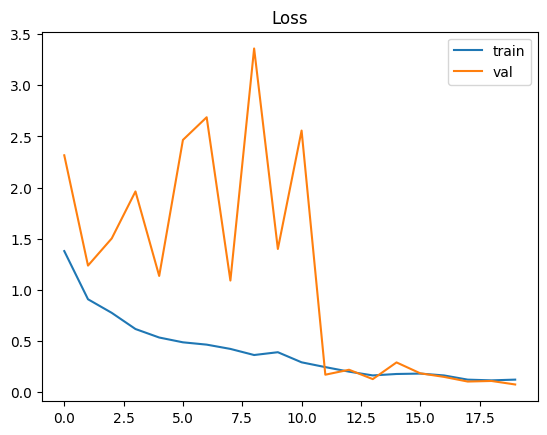

In [15]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.legend()
plt.show()

# Loss
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.legend()
plt.show()

akurasi dari train dan validation sudah stabil dan mririp, menunjukkan tidak terjadi overfitting

Model hasil modifikasi menunjukkan peningkatan performa yang signifikan dibandingkan baseline. Akurasi training dan validation mencapai lebih dari 95% dengan loss yang menurun secara konsisten. Hal ini menunjukkan bahwa penambahan Batch Normalization, Dropout, dan mengurangi kompleksitas model berhasil meningkatkan kemampuan generalisasi dan mengatasi underfitting pada model baseline tadi.

In [16]:
model_2c = model

### 2d.

In [17]:
test_loss, test_acc = model_2b.evaluate(test_data)

print("=== Model 2B (Baseline) ===")
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

y_pred_b = model_2b.predict(test_data)
y_pred_classes_b = np.argmax(y_pred_b, axis=1)

y_true = test_data.classes
class_labels = list(test_data.class_indices.keys())

18/18 [==============================] - 6s 356ms/step - loss: 1.6099 - accuracy: 0.1366
=== Model 2B (Baseline) ===
Test Accuracy: 0.13661202788352966
Test Loss: 1.6098923683166504
18/18 [==============================] - 3s 176ms/step


In [18]:
test_loss, test_acc = model_2c.evaluate(test_data)

print("=== Model 2C (Improved) ===")
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

y_pred_c = model_2c.predict(test_data)
y_pred_classes_c = np.argmax(y_pred_c, axis=1)

18/18 [==============================] - 3s 180ms/step - loss: 0.0798 - accuracy: 0.9763
=== Model 2C (Improved) ===
Test Accuracy: 0.9763205647468567
Test Loss: 0.07983691245317459
18/18 [==============================] - 3s 183ms/step


Nilai loss yang rendah menunjukkan bahwa model tidak hanya menghasilkan prediksi yang benar, tetapi juga memiliki tingkat kepercayaan yang tinggi terhadap prediksinya. Terdapat perbedaan yang sangat signifikan dari model baseline dengan model yang sudah di modifikasi.

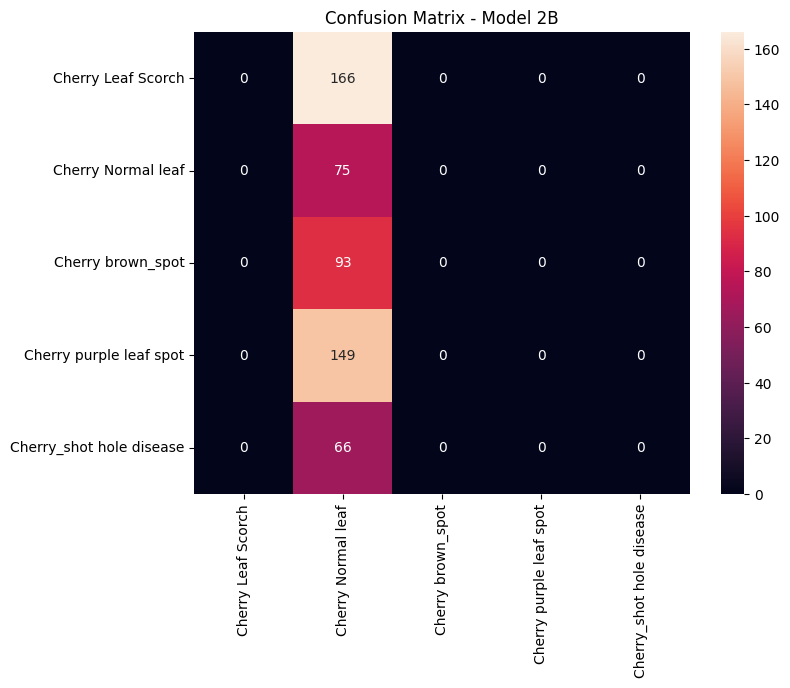

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes_b)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix - Model 2B")
plt.show()

model B tidak mampu belajar untuk membedakan gambar antar kelas karena terjadi underfitting

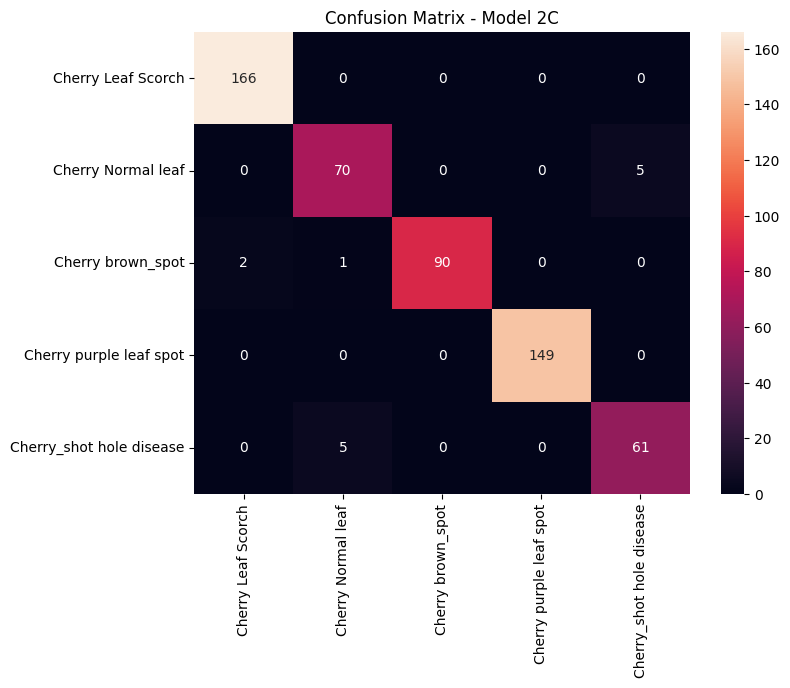

In [20]:
cm = confusion_matrix(y_true, y_pred_classes_c)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix - Model 2C")
plt.show()

Setelah dimodifikasi, pesebaran prediksi jadi jauh lebih merata

Dari plot ini, terlihat bahwa model terkadang keliru dalam membedakan cherry normal leaf dan cherry shot hole disease. Ini mungkin terjadi karena kedua kategori ini memiliki gambar yang cenderun mirip (hanya beda 1 titik kecil saja).

In [24]:
from sklearn.metrics import classification_report

print("=== Classification Report 2B ===")
print(classification_report(y_true, y_pred_classes_b, target_names=class_labels))

=== Classification Report 2B ===
                          precision    recall  f1-score   support

      Cherry Leaf Scorch       0.00      0.00      0.00       166
      Cherry Normal leaf       0.14      1.00      0.24        75
       Cherry brown_spot       0.00      0.00      0.00        93
 Cherry purple leaf spot       0.00      0.00      0.00       149
Cherry_shot hole disease       0.00      0.00      0.00        66

                accuracy                           0.14       549
               macro avg       0.03      0.20      0.05       549
            weighted avg       0.02      0.14      0.03       549



C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.

In [23]:
print("=== Classification Report 2C ===")
print(classification_report(y_true, y_pred_classes_c, target_names=class_labels))

=== Classification Report 2C ===
                          precision    recall  f1-score   support

      Cherry Leaf Scorch       0.99      1.00      0.99       166
      Cherry Normal leaf       0.92      0.93      0.93        75
       Cherry brown_spot       1.00      0.97      0.98        93
 Cherry purple leaf spot       1.00      1.00      1.00       149
Cherry_shot hole disease       0.92      0.92      0.92        66

                accuracy                           0.98       549
               macro avg       0.97      0.97      0.97       549
            weighted avg       0.98      0.98      0.98       549



Berdasarkan hasil evaluasi, model baseline (2B) mengalami underfitting parah dan gagal melakukan klasifikasi dengan baik. Setelah dilakukan modifikasi pada arsitektur dan hyperparameter (2C), performa model meningkat secara signifikan dengan akurasi mencapai 97%. Model mampu membedakan setiap kelas dengan baik dan menunjukkan kemampuan generalisasi yang tinggi. Hal ini membuktikan bahwa modifikasi arsitektur CNN sangat berpengaruh terhadap keberhasilan model dalam mempelajari data.

Nilai F1 score yang tinggi juga berarti terdapat keseimbangan baik antara precision & recall

Namun apakah tidak overfitting?

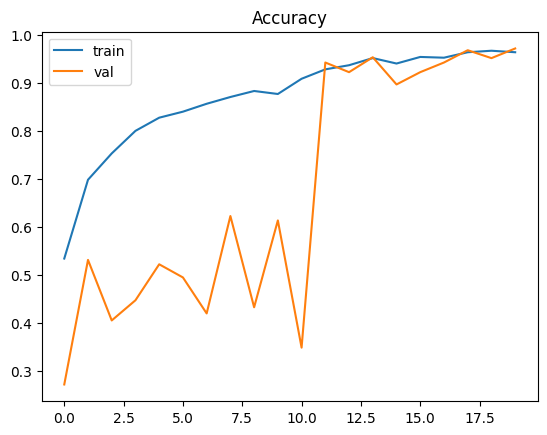

In [25]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.legend()
plt.show()

Dari plot sebelumnya, terlihat bahwa mulai pada epoch ke-11, akurasi training dan validation menjadi relatif mirip dan stabil meningkat. Hal ini menunjukkan bahwa model telah mencapai kondisi konvergen dan tidak mengalami overfitting, karena tidak terdapat perbedaan signifikan antara performa pada data training dan validation.